In [24]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from pathlib import Path
import pandas as pd
import sys

import_path = Path.cwd().parents[1]
sys.path.insert(0, str(import_path))
import feature_utils as futils

In [20]:
root_dir = Path(r"E:\segs_clust_7104")
pc_dir = Path(r"E:\segs_clust_7104\pc_2048")
k_dir = Path(pc_dir / "k_08")

# Paths.
local_feature_root = Path(r"D:\logmel_outputs_9979")
cfg = np.load(root_dir / "config_and_ipca.npz")

Z2 = np.load(pc_dir / "pca2_scores.npy")
labels = np.load(k_dir / "segment_labels.npy")
centers = np.load(k_dir / "kmeans_centers.npy")

print(Z2.shape)
print(labels.shape)

k = 8

(653346, 2)
(653346,)


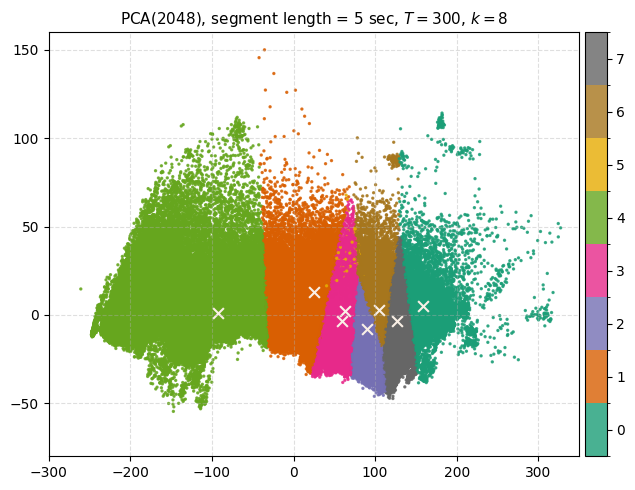

In [19]:
plt.figure(figsize=(7, 5))
fig = plt.gcf()
cmap = plt.get_cmap("Dark2", k)
norm = mcolors.BoundaryNorm(np.arange(-0.5, k + 0.5, 1), cmap.N)
sc = plt.scatter(Z2[:, 0], Z2[:, 1], c=labels, s=2, cmap=cmap, norm=norm, alpha=0.8)
plt.scatter(centers[:, 0], centers[:, 1], c="linen", s=60, marker="x", label="Centroids")
plt.title("PCA(2048), segment length = 5 sec, $T = 300$, $k = 8$", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.4)
ax = plt.gca()
ax.set_ylim(-80, 160)
ax.set_xlim(-300, 350)
colorbar = plt.colorbar(sc, ticks=np.arange(k), pad=0.01)
plt.tight_layout()
report_save_path = Path(r"C:\Users\Lindholm\Dropbox\BSc\report_figures\pca_kmeans_clusters")
plt.savefig(report_save_path / "pca2_kmeans_8clusters_fullset_segs5s_downT300.png", dpi=300)
plt.show()